# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [9]:
#Seu código aqui

df.isnull().values.any()

df.isnull().sum()

(df.isnull().sum() / len(df)) *100


Valor_Aluguel       0.0
Valor_Condominio    0.0
Metragem            0.0
N_Quartos           0.0
N_banheiros         0.0
N_Suites            0.0
N_Vagas             0.0
dtype: float64

# Não há dados faltantes

# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

In [10]:
#Seu código aqui

df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


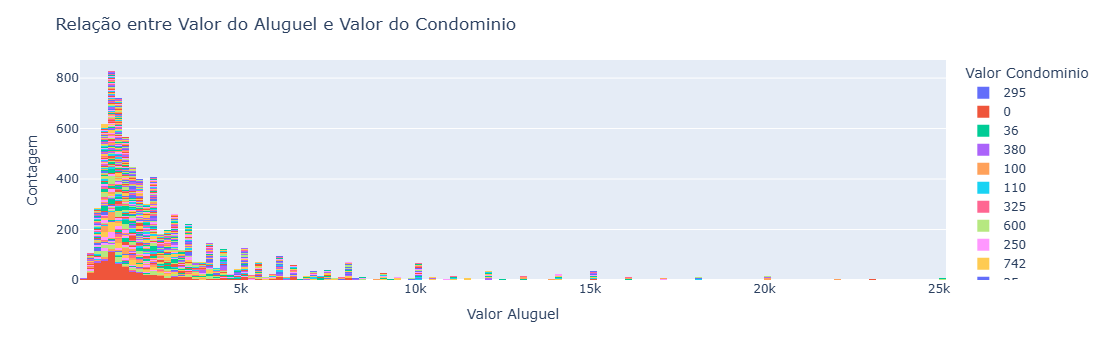

In [13]:
fig = px.histogram(df, x='Valor_Aluguel', color='Valor_Condominio', barmode='stack')

# Layout
fig.update_layout(title='Relação entre Valor do Aluguel e Valor do Condominio',
                  xaxis_title='Valor Aluguel',
                  yaxis_title='Contagem',
                  legend_title='Valor Condominio')
fig.show()

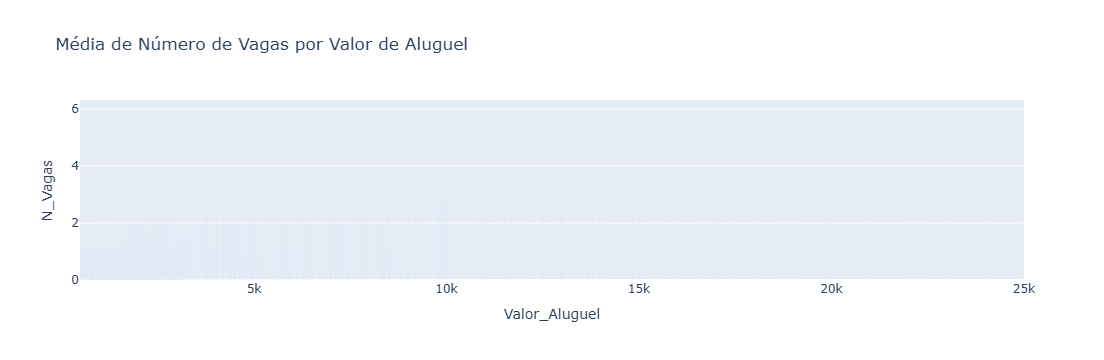

In [15]:
# Calculando a mediana de Número de Vagas por Valor de Aluguel
media_n_de_vagas_valor_aluguel = df.groupby('Valor_Aluguel')['N_Vagas'].median().reset_index()

# Criar gráfico de barras
fig = px.bar(media_n_de_vagas_valor_aluguel, x='Valor_Aluguel', y='N_Vagas',
             title='Média de Número de Vagas por Valor de Aluguel',
             labels={'Valor_Aluguel': 'Média de Número de Vagas', 'Valor_Aluguel': 'Valor_Aluguel'})
fig.show()

# Aqui gostaria de verificar qual a media de numero de vagas por aluguel. Olhando o gráfico vazio percebi que número de vagas devem se referir a vagas de garagem e não de apartamentos disponíveis para aluguel. 

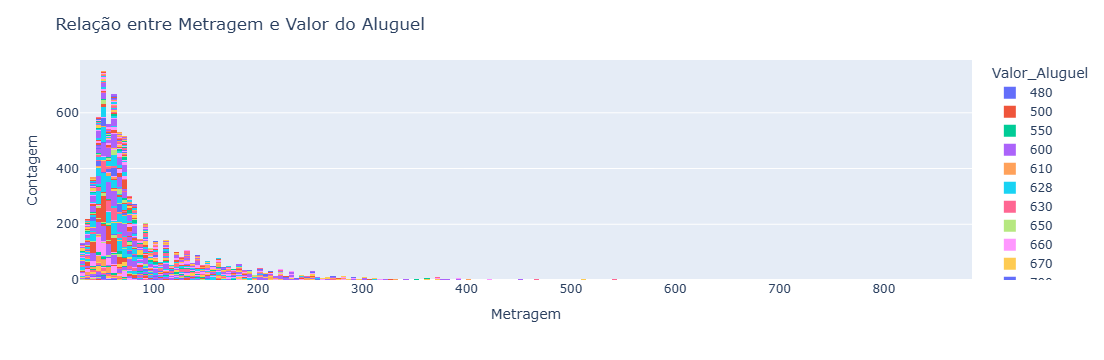

In [16]:
# relação entre metragem e valor do aluguel

fig = px.histogram(df, x='Metragem', color='Valor_Aluguel', barmode='stack')
fig.update_layout(title='Relação entre Metragem e Valor do Aluguel',
                  xaxis_title='Metragem',
                  yaxis_title='Contagem',
                  legend_title='Valor_Aluguel')
fig.show()

# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




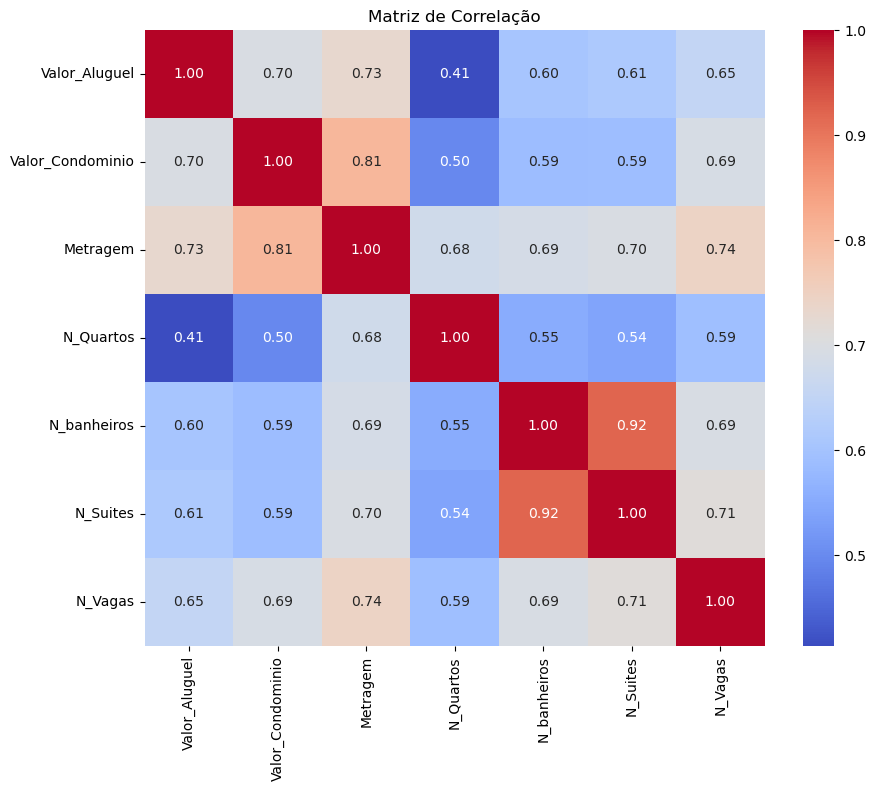

In [17]:
#Seu código aqui

correlation_matrix = df.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()


B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [19]:
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

Dica: Para separar em treino e teste usamos o train_test_split, como visto nas aulas de pré modelagem.

In [20]:
# Seu código aqui

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [21]:
X_train

,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
6931,1350,176,3,4,3,3
4125,680,70,1,1,0,2
6079,650,66,2,1,0,1
5044,655,68,3,2,1,1
2299,330,33,1,1,0,1
...,...,...,...,...,...,...
3772,450,48,2,2,1,1
5191,570,34,1,1,0,1
5226,976,95,2,2,1,1
5390,550,74,3,3,1,2


In [22]:
X_test

,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
3885,484,50,2,1,0,1
4661,680,50,2,1,0,1
1038,0,58,2,2,1,1
5867,1226,127,3,1,0,2
5099,697,90,4,3,1,2
...,...,...,...,...,...,...
4689,1250,160,3,3,1,2
5313,530,43,1,2,1,1
5624,1250,147,4,4,2,3
4647,650,53,2,1,0,1


In [23]:
y_train

6931    10000
4125     2200
6079     4500
5044     2900
2299     1500
        ...  
3772     2000
5191     3000
5226     3000
5390     3200
860      1100
Name: Valor_Aluguel, Length: 5402, dtype: int64

In [24]:
y_test

3885    2100
4661    2500
1038    1200
5867    4000
5099    3000
        ... 
4689    2550
5313    3100
5624    3500
4647    2500
4453    2500
Name: Valor_Aluguel, Length: 1801, dtype: int64

In [25]:
print("Tamanho de X_train:", X_train.shape)

Tamanho de X_train: (5402, 6)


In [26]:
print("Tamanho de X_test:", X_test.shape)

Tamanho de X_test: (1801, 6)


In [27]:
print("Tamanho de y_train:", y_train.shape)

Tamanho de y_train: (5402,)


In [28]:
print("Tamanho de y_test:", y_test.shape)

Tamanho de y_test: (1801,)


# 3 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [64]:
X = X_train[['Metragem']]  # Variável independente (características)
y = y_train # Variável dependente (rótulo)
# se você deu um nome diferente para x train e y train, altere no código.

In [65]:
#Crie seu modelo aqui, usando LinearRegression e as bases de treino.

In [66]:
X

,Metragem
6931,176
4125,70
6079,66
5044,68
2299,33
...,...
3772,48
5191,34
5226,95
5390,74


B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

In [67]:
#Seu código Aqui

regressao_metragem = LinearRegression()

regressao_metragem.fit(X,y)

LinearRegression()

In [68]:
regressao_metragem.intercept_

-103.17820863080124

In [69]:
regressao_metragem.coef_

array([34.70818769])

Nossa equação seria:  

c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [70]:
#Seu código aqui

r_quadrado = regressao_metragem.score(X, y)
print(f"R-quadrado do modelo de treinamento: {r_quadrado}")

R-quadrado do modelo de treinamento: 0.5213271756253639


# O modelo se ajusta em 52% aos dados 

D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

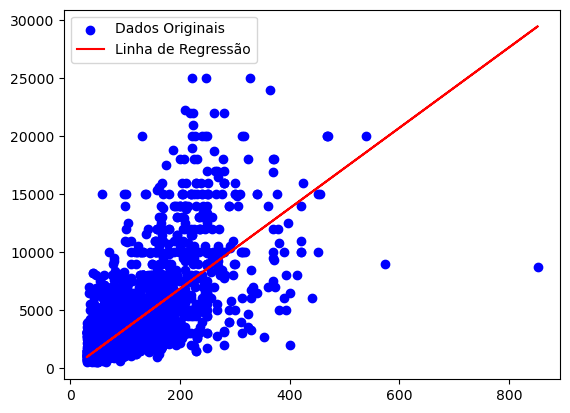

In [71]:
# Seu código aqui

# Plotar os dados originais
plt.scatter(X, y, color='blue', label='Dados Originais')

# Plotar a linha de regressão
plt.plot(X, regressao_metragem.predict(X), color='red', label='Linha de Regressão')
plt.legend()
plt.show()

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [73]:
X_test = X_test[['Metragem']]  # Variável independente (características)
y_test = y_test # Variável dependente (rótulo)

In [74]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
previsoes = regressao_metragem.predict(X_test)

# Avaliando o desempenho do modelo usando métricas como o R²
r2 = regressao_metragem.score(X_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)


Coeficiente de Determinação (R²) nos Dados de Teste: 0.5651600449476675


Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

# Acredito que a diferença não foi grande então o modelo vai funcionar bem com novos dados.

Escreva sua resposta aqui.

# 4 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [78]:
#seu código aqui

X = X_train[['Metragem', 'Valor_Condominio', 'N_Quartos', 'N_banheiros', 'N_Suites', 'N_Vagas']]  # Variável independente (características)
y = y_train # Variável dependente (rótulo)

B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [79]:
#seu código aqui

X

,Metragem,Valor_Condominio,N_Quartos,N_banheiros,N_Suites,N_Vagas
6931,176,1350,3,4,3,3
4125,70,680,1,1,0,2
6079,66,650,2,1,0,1
5044,68,655,3,2,1,1
2299,33,330,1,1,0,1
...,...,...,...,...,...,...
3772,48,450,2,2,1,1
5191,34,570,1,1,0,1
5226,95,976,2,2,1,1
5390,74,550,3,3,1,2


C) Traga o valor do R quadrado e avalie o valor encontrado.

In [84]:
#seu código aqui

regressao_variaveis = LinearRegression()

regressao_variaveis.fit(X,y)

LinearRegression()

In [85]:
regressao_variaveis.intercept_

411.92895077376534

In [86]:
regressao_variaveis.coef_

array([  20.72122898,    0.77302112, -659.00604215,  240.76046013,
        340.61447028,  522.98401929])

D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

In [87]:
#seu código aqui

r_quadrado = regressao_variaveis.score(X, y)
print(f"R-quadrado do modelo de treinamento: {r_quadrado}")

R-quadrado do modelo de treinamento: 0.5971610197647366


E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

Digite sua resposta aqui

In [ ]:
# O modelo de regressão multipla apresentou a porcentagem de 59% e ele parece melhor porque o resultado foi maior. Acredito que o conjunto de variáveis contribuiu para isso.